# Team Info

- **Youssef ElNahas** - *4311779*
- **Mohammed Sattar** - *4310129*
- **Abdullah AlSerri** - *4211780*


# Data Info

*Main Website*: https://lyricstranslate.com/en/songs/
- **FEATURE** SO **REASON**
- Contains Information About Arabic Song Lyrics SO it contains arabic text sufficient to create a dataset
- Contains Information About the specific dialect SO saves time for annotation
- HTML Very Readable SO Simplicity in extraction

# Data Collection and Annotation

## Data Collection

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from io import StringIO
import re

# Language mapping
languages = {
    'Arabic (Egyptian)': '1037494',
    'Arabic (Levantine)': '1037493',
    'Arabic (Maghrebi)': '1037522'
}

base_url = 'https://lyricstranslate.com/en/songs/{lang_id}/none/none/0/none/0'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

def get_songs_for_language(lang_name, lang_id):
    songs = []
    page = 1
    while True:
        # print(f"Fetching page {page} for language ID {lang_id}...")
        url = base_url.format(lang_id=lang_id) + (f'?page={page}' if page > 1 else '')
        response = requests.get(url, headers=headers)
        if response.status_code != 200:
            break
        soup = BeautifulSoup(response.text, 'html.parser')
        table = soup.find('div', class_='t-s-r')
        if not table:
            break
        rows = table.find_all('div', class_='d-tr')[1:]  # Skip header
        if not rows:
            break
        for row in rows:
            cells = row.find_all('div')
            # print(cells)
            # exit()
            if "," in cells[4].text.strip():
                continue  # Skip songs with multiple languages
            artist_a = cells[1].find('div', class_='att')
            song_a = cells[2].find('a')
            if artist_a and song_a:
                artist = artist_a.text.strip()
                song = song_a.text.strip()
                song_url = 'https://lyricstranslate.com' + song_a['href']
                artist = str(artist)
                artist = artist.replace('<div class="att">', "").replace("</div>", "")
                songs.append((artist, song, song_url))
        page += 1
        if page == 6:  # Limit to first 6 pages
            break
    return songs

## Data Annotation

In [ ]:
def extract_lyrics_and_check_language(song_url, target_lang):
    response = requests.get(song_url, headers=headers)
    if response.status_code != 200:
        return None, None
    soup = BeautifulSoup(response.text, 'html.parser')
    song_node_text = soup.find('div', class_='song-node-text')
    song_body = song_node_text.find('div', id='song-body') 
    lyrics = song_body.get_text(separator=" ", strip=True)
    return lyrics

## Main

In [ ]:
def main():
    all_data = []
    unique_id = 0
    lang_count = 0
    for lang_name, lang_id in languages.items():
        print(f"Processing {lang_name}...")
        songs = get_songs_for_language(lang_name, lang_id)
        for artist, song, url in songs:
            song_lang = ""
            lyrics = extract_lyrics_and_check_language(url, lang_name)
            if lang_id == "1037494":
                song_lang = "Egyptian"
            elif lang_id == "1037493":
                song_lang = "Levantine"
            elif lang_id == "1037522":
                song_lang = "Maghrebi"
            if lyrics:
                all_data.append({
                    'ID': f"{unique_id:04d}",
                    'Artist': artist,
                    'Song': song,
                    'Dialect': song_lang,
                    'Lyrics': lyrics
                })
                print(f"Added {unique_id:04d}: {artist} - {song} ({song_lang})")
                unique_id += 1
                if unique_id > 9999:
                    break
        if unique_id > 9999:
            break
    
    df = pd.DataFrame(all_data)
    df.to_csv('songs_lyrics.csv', index=False)

if __name__ == "__main__":
    main()

# Data Cleaning

## Duplicate Removal

In [ ]:
import pandas as pd

# Load your CSV
df = pd.read_csv("songs_lyrics.csv")

# Check duplicates in the Lyrics column
duplicates = df[df.duplicated(subset=["Lyrics"], keep=False)]
print("Found duplicate lyrics:\n")
print(duplicates)

# Remove duplicates (keep the first occurrence only)
df_no_duplicates = df.drop_duplicates(subset=["Lyrics"], keep="first")

# Save to new CSV
df_no_duplicates.to_csv("songs_no_duplicates.csv", index=False)

print("\nDuplicates removed. Saved as songs_no_duplicates.csv")


## Diacritics and Space Removal

In [ ]:
import pandas as pd
import re

# Load CSV
df = pd.read_csv("songs_no_duplicates.csv")

# Function to remove Arabic diacritics
def remove_diacritics(text):
    return re.sub(r"[\u064B-\u065F]", "", str(text))

# Strip whitespace and remove diacritics from Lyrics
df["Lyrics"] = df["Lyrics"].astype(str).str.strip().apply(remove_diacritics)

# Also strip Song names (without removing diacritics there)
df["Song"] = df["Song"].astype(str).str.strip()

# Save cleaned file
df.to_csv("songs_cleaned.csv", index=False)

print("Cleaning done! Saved as songs_cleaned.csv")


# Data Analysis & Visualization

In [4]:
#!pip install pandas matplotlib wordcloud scikit-learn seaborn dython arabic-reshaper python-bidi

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import seaborn as sns
from dython.nominal import associations
import numpy as np
import re
from collections import Counter, defaultdict
from matplotlib.font_manager import FontProperties
import arabic_reshaper
from bidi.algorithm import get_display


In [6]:
# -------------------------
# Load dataset
# -------------------------
df = pd.read_csv(r"/home/mohammed/Documents/GitHub/WebScraper/app/songs_cleaned.csv")

## Helper Functions & Config

In [7]:
# ---------- CONFIG ----------
# CSV_PATH = "songs_cleaned.csv"   # path to your CSV
LYRICS_COL = "Lyrics"
DIALECT_COL = "Dialect"
ARTIST_COL = "Artist"
TOP_K = 15                        # number of unique repeated words to show per dialect


# Minimal Arabic stopwords
STOPWORDS = set([
    "و", "في", "من", "على", "ما", "لا", "يا", "إلى", "عن", "هو", "هي",
    "ان", "انا", "انت", "إنت", "ده", "دي", "هوه", "هيه", "كل", "مع", "كان",
    "الى", "اي", "ايه", "ايضا", "لكن", "بعد", "قبل", "هذا", "هذه", "ليه",
    "لي", "كم", "يا", "أيوه", "ايوه", "ماشي", "فيه", "ليه", "اه", "آه"
])

In [8]:
# ---------- TEXT NORMALIZATION ----------
# Remove Arabic diacritics and normalize alef/ta marbuta/ya/hamza etc.
_arabic_diacritics_re = re.compile(
    r'[\u0610-\u061A\u064B-\u065F\u0670\u06D6-\u06DC\u06DF-\u06E8\u06EA-\u06ED]', flags=re.UNICODE
)

def normalize_arabic(text: str) -> str:
    if not isinstance(text, str):
        return ""
    s = text
    # Remove tashkeel (diacritics)
    s = _arabic_diacritics_re.sub("", s)
    # Normalize alef variants to bare alef
    s = re.sub(r'[إأآا]', 'ا', s)
    # Normalize hamza on waw/yeh
    s = re.sub(r'[ؤ]', 'و', s)
    s = re.sub(r'[ئ]', 'ي', s)
    # Normalize taa marbuta to heh
    s = re.sub(r'ة', 'ه', s)
    # Remove tatweel (elongation)
    s = re.sub(r'ـ+', '', s)
    # Remove punctuation (keep Arabic letters and numbers and basic latin)
    s = re.sub(r"[^\w\u0600-\u06FF\s']", " ", s)
    # Collapse whitespace
    s = re.sub(r'\s+', ' ', s).strip()
    return s

In [9]:
# Tokenization regex captures Arabic words and alphanumerics
TOKEN_RE = re.compile(r"[\u0600-\u06FF\u0750-\u077F\u08A0-\u08FF\w']+", flags=re.UNICODE)

def tokenize(text: str):
    text = normalize_arabic(text)
    tokens = TOKEN_RE.findall(text)
    # lowercase Latin tokens, keep Arabic as-is (Arabic has no lower/upper)
    tokens = [t.lower().strip() for t in tokens if t.strip()]
    # filter stopwords and short tokens
    tokens = [t for t in tokens if (t not in STOPWORDS) and (len(t) > 1)]
    return tokens

In [10]:
# ---------- HELPER: reshape Arabic text for correct display ----------
def ar(x):
    """Reshape and reorder Arabic text for proper display in matplotlib."""
    return get_display(arabic_reshaper.reshape(x))

## Dialect Distribution

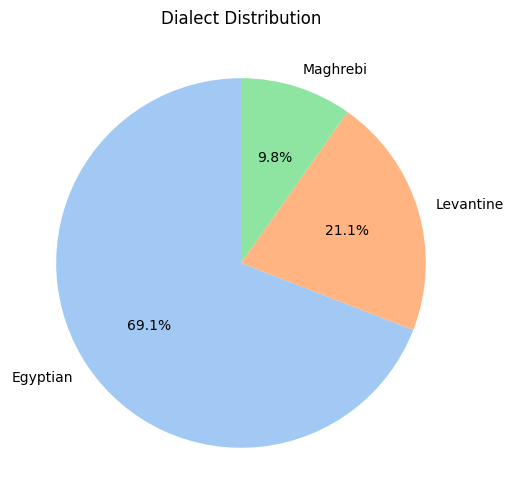

In [11]:
# -------------------------
# 1. Dialect Distribution Pie Chart
# -------------------------
dialect_counts = df['Dialect'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(dialect_counts, labels=dialect_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Dialect Distribution')
plt.show()

## Artist's Song Count

/tmp/ipykernel_37417/3370249945.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=artist_counts.values, y=artist_counts.index, palette=palette)


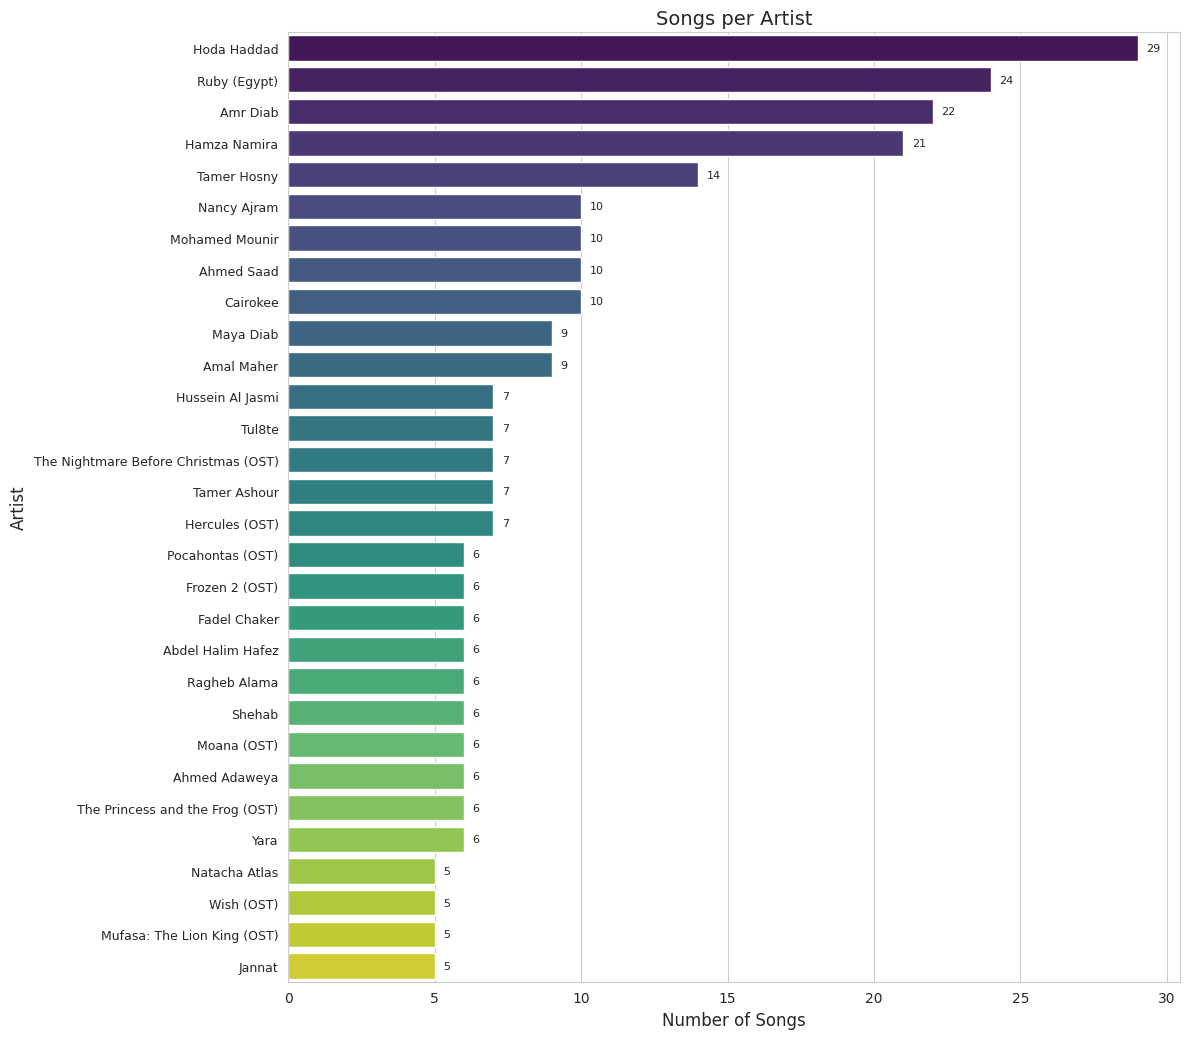

In [12]:
def artist_song_counts(df, artist_col='Artist', top_n=None,
                                       palette='viridis'):
    """
    Horizontal bar chart of song counts per artist.
    - df: pandas DataFrame with an 'Artist' column.
    - artist_col: name of artist column in df (default 'Artist').
    - top_n: if int, show only top_n artists by song count. If None, show all.
    - palette: seaborn/matplotlib palette name.
    """
    # 1) compute counts
    artist_counts = df[artist_col].value_counts()

    # 2) optionally restrict to top_n
    if top_n is not None and isinstance(top_n, int):
        artist_counts = artist_counts.nlargest(top_n)

    artist_counts = artist_counts.sort_values(ascending=False)

    n_artists = len(artist_counts)

    # 4) dynamic figure size - width fixed, height grows with number of artists
    fig_width = 12
    fig_height = max(6, 0.35 * n_artists)
    plt.figure(figsize=(fig_width, fig_height))

    sns.set_style("whitegrid")
    ax = sns.barplot(x=artist_counts.values, y=artist_counts.index, palette=palette)

    # 5) labels and title
    ax.set_xlabel("Number of Songs", fontsize=12)
    ax.set_ylabel("Artist", fontsize=12)
    ax.set_title("Songs per Artist", fontsize=14)

    # 6) y-label font size scaling so long lists remain readable
    if n_artists <= 20:
        y_fontsize = 11
    elif n_artists <= 50:
        y_fontsize = 9
    elif n_artists <= 100:
        y_fontsize = 7
    else:
        y_fontsize = 6
    plt.yticks(fontsize=y_fontsize)

    # 7) annotate bars with counts
    x_max = artist_counts.values.max() if n_artists > 0 else 1
    for i, v in enumerate(artist_counts.values):
        ax.text(v + 0.01 * x_max, i, str(v), va='center', fontsize=max(8, y_fontsize-1))

    # 8) layout & optional save
    plt.tight_layout()
    plt.show()


# 1) Plot all artists
# artist_song_counts(df)

# 2) Plot only the top 30 artists
artist_song_counts(df, top_n=30)


## Word Counting

In [13]:
TOP_K = 15

### Common Words Overall

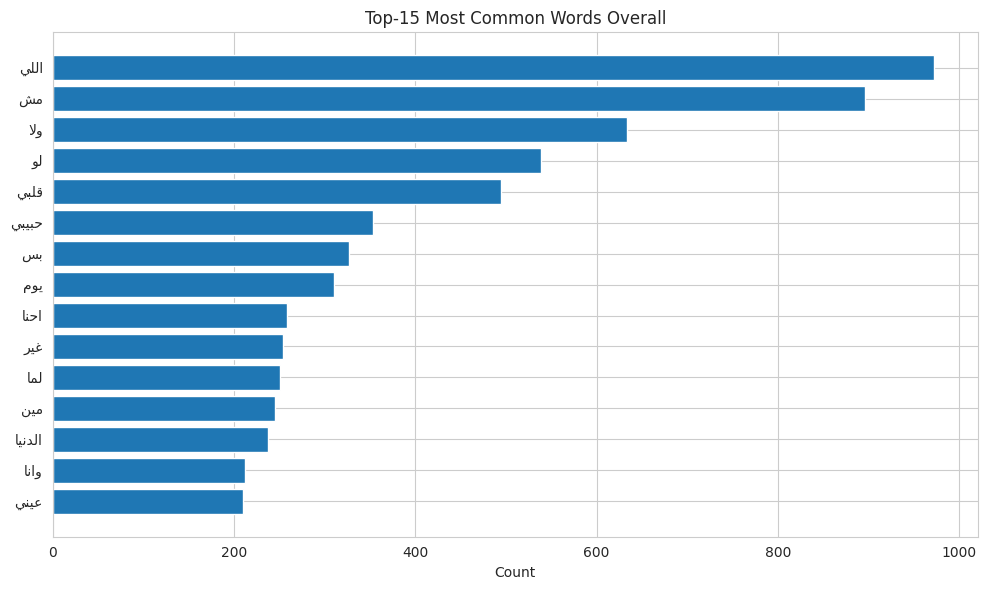

In [14]:
# ---------- AGGREGATE ALL LYRICS ----------
all_lyrics = " ".join(df[LYRICS_COL].astype(str).fillna("").tolist())

# ---------- TOKENIZE ----------
all_tokens = tokenize(all_lyrics)

# ---------- COUNT WORDS ----------
word_counts = Counter(all_tokens)

# ---------- GET TOP-K ----------
top_words = word_counts.most_common(TOP_K)

# Convert to DataFrame for plotting
df_top = pd.DataFrame(top_words, columns=["word", "count"])

# ---------- HELPER: reshape Arabic ----------
def ar(x):
    return get_display(arabic_reshaper.reshape(x))

# ---------- PLOTTING ----------
plt.figure(figsize=(10,6))
y = [ar(w) for w in df_top["word"]]
x = df_top["count"]
plt.barh(y[::-1], x[::-1])  # reverse to have largest on top
plt.xlabel("Count")
plt.title(f"Top-{TOP_K} Most Common Words Overall")
plt.tight_layout()
plt.show()


### Common Words per Dialect

/home/mohammed/anaconda3/envs/sahmalgo/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


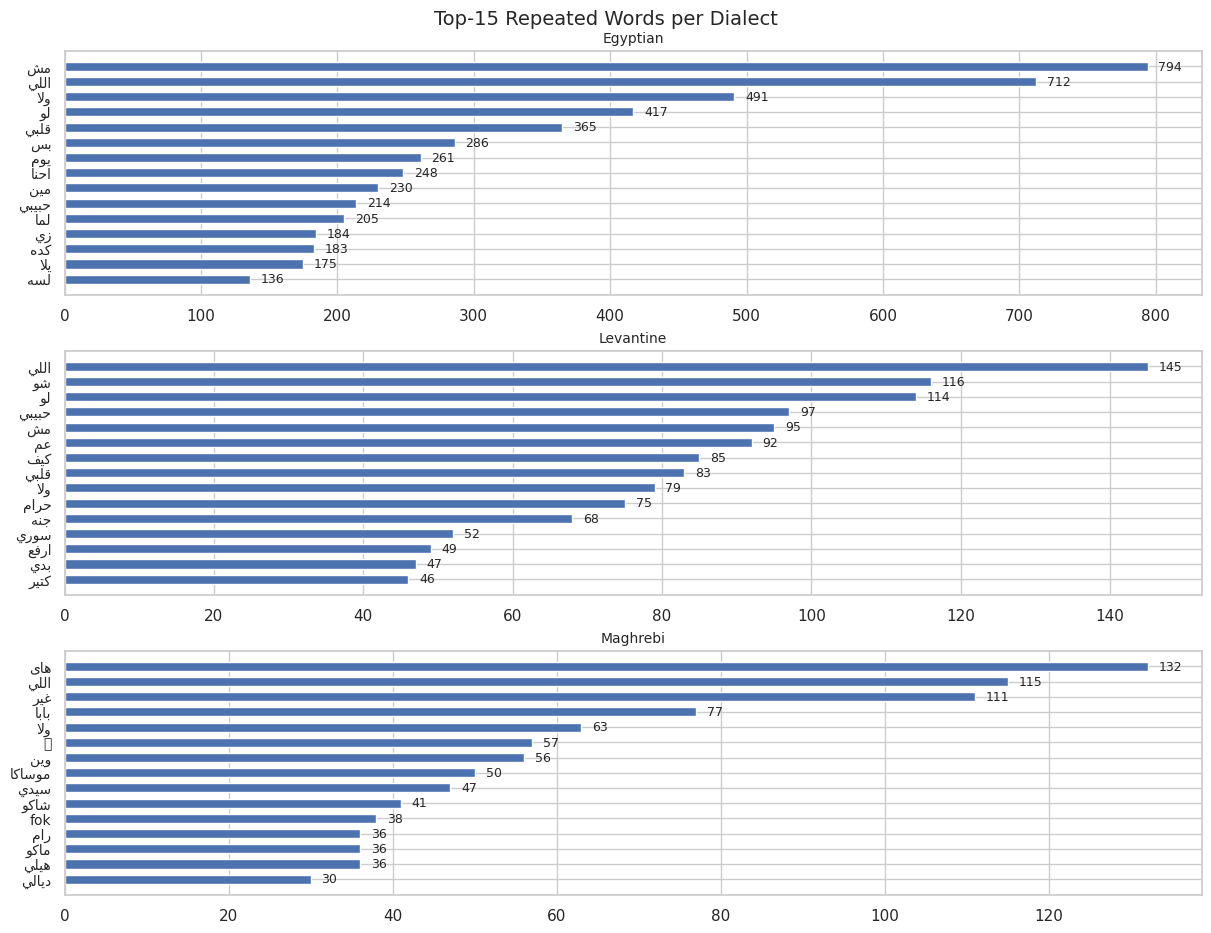

In [15]:
# Build a document per dialect (concatenate lyrics of that dialect)
dialect_docs = {}
dialect_tokens = {}
for dialect, group in df.groupby(DIALECT_COL):
    all_text = " ".join(group[LYRICS_COL].astype(str).fillna("").tolist())
    norm = normalize_arabic(all_text)
    tokens = tokenize(norm)
    dialect_docs[dialect] = " ".join(tokens)          # for TF-IDF
    dialect_tokens[dialect] = Counter(tokens)         # for raw counts

dialects = sorted(dialect_docs.keys())
documents = [dialect_docs[d] for d in dialects]

# ---------- TF-IDF over dialect-level documents ----------
# Use a token_pattern that accepts Arabic characters
token_pattern = r"(?u)\b[\w\u0600-\u06FF']+\b"
vectorizer = TfidfVectorizer(token_pattern=token_pattern, lowercase=False, max_features=10000)
tfidf = vectorizer.fit_transform(documents)   # shape: (n_dialects, n_terms)
terms = np.array(vectorizer.get_feature_names_out())

# For each dialect (row), get top-k terms by TF-IDF
top_terms_per_dialect = {}
for i, dialect in enumerate(dialects):
    row = tfidf[i].toarray().ravel()
    # get indices of top terms
    top_idx = np.argsort(row)[-TOP_K:][::-1]
    top_terms = terms[top_idx]
    top_scores = row[top_idx]
    top_terms_per_dialect[dialect] = list(zip(top_terms, top_scores))

# ---------- Build plotting data: use raw counts for bar lengths ----------
plot_data = {}
for dialect in dialects:
    items = top_terms_per_dialect[dialect]
    words = [w for w, s in items]
    counts = [dialect_tokens[dialect].get(w, 0) for w in words]
    plot_data[dialect] = pd.DataFrame({"word": words, "count": counts})
    
    

# ---------- PLOTTING ----------
sns.set(style="whitegrid")
n_dialects = len(dialects)
fig_height = max(3, 3 * n_dialects * 1.0)
fig_width = 12
fig, axes = plt.subplots(n_dialects, 1, figsize=(fig_width, fig_height), constrained_layout=True)

if n_dialects == 1:
    axes = [axes]

for ax, dialect in zip(axes, dialects):
    df_plot = plot_data[dialect].sort_values("count")  # ascending to plot horizontal bars
    y = [ar(word) for word in df_plot["word"]]        # reshape Arabic words
    x = df_plot["count"]
    ax.barh(y, x, height=0.6)
    ax.set_title(ar(dialect), fontsize=10)           # reshape dialect name if Arabic
    ax.tick_params(axis='y', labelsize=10)
    # show count at the end of each bar
    for i, v in enumerate(x):
        ax.text(v + max(1, 0.01 * max(x)), i, str(v), va='center', fontsize=9)

plt.suptitle(f"Top-{TOP_K} Repeated Words per Dialect", fontsize=14, y=1.02)
plt.show()


# # Optional: print top words per dialect to console
# print("\nTop words per dialect (term, tfidf_score, raw_count):")
# for dialect in dialects:
#     print("\n----", dialect, "----")
#     for term, score in top_terms_per_dialect[dialect]:
#         raw = dialect_tokens[dialect].get(term, 0)
#         print(f"{term}\t{score:.4f}\t{raw}")

## Artist-Dialect Heatmap

Total records in contingency table: 644


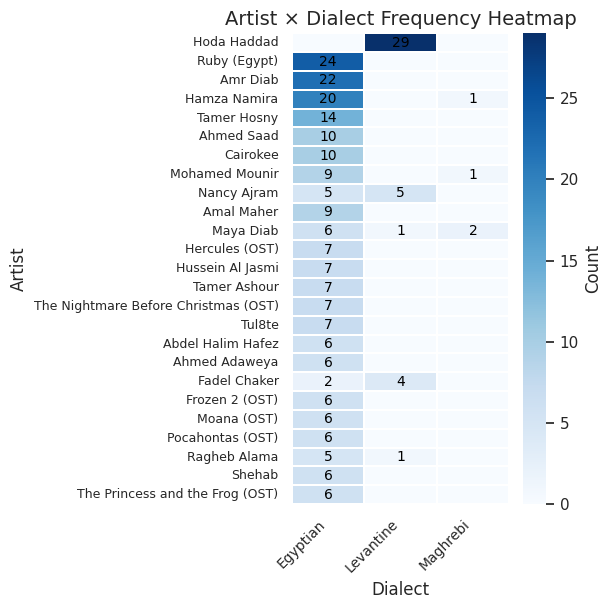

In [16]:
def artist_dialect_heatmap(
    df,
    artist_col='Artist',
    dialect_col='Dialect',
    top_artists=None,      # int or None: if int, keep only top N artists by total songs
    top_dialects=None,     # int or None: if int, keep only top N dialects by total songs
    hide_zeros=True,       # if True, don't annotate zero cells (reduces clutter)
    cmap='Blues'
):
    """
    Plot a cleaned Artist x Dialect frequency heatmap with dynamic sizing and readable labels.
    """
    # 1) Build contingency table
    corr_matrix = pd.crosstab(df[artist_col], df[dialect_col])
    total_records = int(corr_matrix.values.sum())
    print(f"Total records in contingency table: {total_records:,}")

    # 2) Optionally select top artists / dialects
    if top_artists is not None:
        top_artist_names = corr_matrix.sum(axis=1).nlargest(top_artists).index
        corr_matrix = corr_matrix.loc[top_artist_names]
    if top_dialects is not None:
        top_dialect_names = corr_matrix.sum(axis=0).nlargest(top_dialects).index
        corr_matrix = corr_matrix[top_dialect_names]

    # 3) Sort artists by total counts (descending) so the biggest appear at top after invert
    corr_matrix = corr_matrix.loc[corr_matrix.sum(axis=1).sort_values(ascending=False).index]

    # 4) Compute sizes & font scaling heuristics
    n_artists, n_dialects = corr_matrix.shape
    if n_artists == 0 or n_dialects == 0:
        raise ValueError("Resulting contingency table is empty. Check your dataframe and columns.")

    # dynamic figsize (width x height)
    fig_width = max(6, 0.6 * n_dialects)    # widen with more dialects
    fig_height = max(6, 0.25 * n_artists)   # grow with artists
    plt.figure(figsize=(fig_width, fig_height))

    # annotation matrix: hide zeros if requested
    annot = corr_matrix.astype(str).values
    if hide_zeros:
        annot = np.where(corr_matrix.values == 0, "", annot)

    # annotation font size: scale with number of cells
    n_cells = n_artists * n_dialects
    if n_cells <= 100:
        annot_fs = 10
    elif n_cells <= 300:
        annot_fs = 8
    elif n_cells <= 800:
        annot_fs = 7
    else:
        annot_fs = 6

    # tick font sizes
    if n_artists <= 20:
        ytick_fs = 11
    elif n_artists <= 50:
        ytick_fs = 9
    elif n_artists <= 100:
        ytick_fs = 7
    else:
        ytick_fs = 6

    if n_dialects <= 6:
        xtick_fs = 10
    elif n_dialects <= 12:
        xtick_fs = 9
    else:
        xtick_fs = 8

    # 5) Plot heatmap
    ax = sns.heatmap(
        corr_matrix,
        annot=annot,
        fmt='',
        cmap=cmap,
        linewidths=0.3,
        linecolor='white',
        cbar_kws={'label': 'Count'},
        annot_kws={"fontsize": annot_fs, "color": "black"}
    )

    # 6) Set tick labels
    # rotate x labels
    plt.xticks(rotation=45, ha='right', fontsize=xtick_fs)
    plt.yticks(rotation=0, fontsize=ytick_fs)

    # 7) Labels and title
    plt.xlabel(dialect_col, fontsize=12)
    plt.ylabel(artist_col, fontsize=12)
    plt.title(f"{artist_col} × {dialect_col} Frequency Heatmap", fontsize=14)

    plt.tight_layout()
    plt.show()


# 1) Plot all
# artist_dialect_heatmap(df)

# 2) reduce top_artists
artist_dialect_heatmap(df, top_artists=25)


## Artist-Dialect Correrlation Matrix

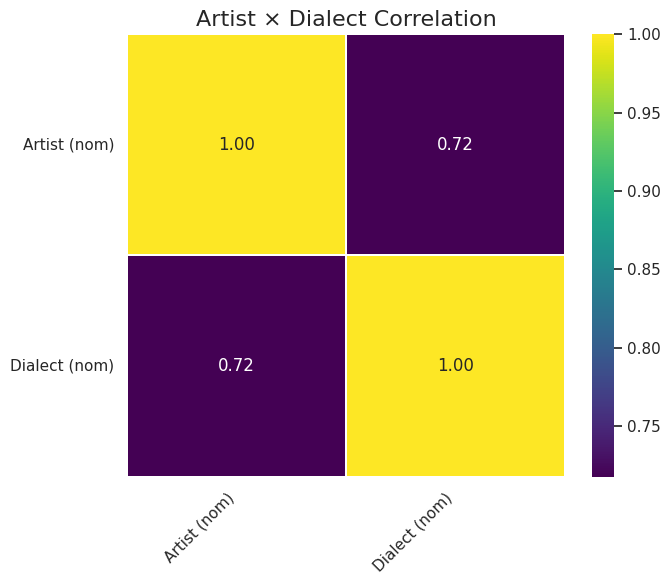

In [17]:
# Compute correlations using Dython
corr_result = associations(
    df[['Artist', 'Dialect']],
    nominal_columns=['Artist', 'Dialect'],
    mark_columns=True,
    plot=False
)

# 'corr_result' contains the correlation matrix
corr_matrix = corr_result['corr']

# -------------------------
# Plot heatmap
# -------------------------
plt.figure(figsize=(7, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.3,
    linecolor='white'
)

plt.title("Artist × Dialect Correlation", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
